In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv('/content/IPL_Ball_by_Ball_2008_2022.csv')

In [13]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225954 entries, 0 to 225953
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ID                 225954 non-null  int64 
 1   innings            225954 non-null  int64 
 2   overs              225954 non-null  int64 
 3   ballnumber         225954 non-null  int64 
 4   batter             225954 non-null  object
 5   bowler             225954 non-null  object
 6   non-striker        225954 non-null  object
 7   extra_type         12049 non-null   object
 8   batsman_run        225954 non-null  int64 
 9   extras_run         225954 non-null  int64 
 10  total_run          225954 non-null  int64 
 11  non_boundary       225954 non-null  int64 
 12  isWicketDelivery   225954 non-null  int64 
 13  player_out         11151 non-null   object
 14  kind               11151 non-null   object
 15  fielders_involved  7988 non-null    object
 16  BattingTeam        2

Available columns in the DataFrame:
Index(['ID', 'innings', 'overs', 'ballnumber', 'batter', 'bowler',
       'non-striker', 'extra_type', 'batsman_run', 'extras_run', 'total_run',
       'non_boundary', 'isWicketDelivery', 'player_out', 'kind',
       'fielders_involved', 'BattingTeam'],
      dtype='object')


In [15]:
df = df[['batter', 'bowler', 'batsman_run', 'BattingTeam']]
df.dropna(inplace=True)

In [18]:
df['recent_form_runs'] = (
    df.groupby('batter')['batsman_run']
    .rolling(window=5)
    .mean()
    .reset_index(level=0, drop=True)
)

In [20]:
venue_stats = df.groupby(['batter'])['batsman_run'].mean().reset_index()
venue_stats.rename(columns={'batsman_run': 'venue_avg_runs'}, inplace=True)

In [22]:
opponent_stats = df.groupby(['batter', 'bowler'])['batsman_run'].mean().reset_index()
opponent_stats.rename(columns={'batsman_run': 'avg_runs_vs_bowler'}, inplace=True)

In [24]:
career_stats = df.groupby('batter')['batsman_run'].mean().reset_index()
career_stats.rename(columns={'batsman_run': 'career_avg_runs'}, inplace=True)

In [26]:
features = df.merge(career_stats, on='batter', how='left')
features = features.merge(venue_stats, on='batter', how='left')
features = features.merge(opponent_stats, on=['batter', 'bowler'], how='left')

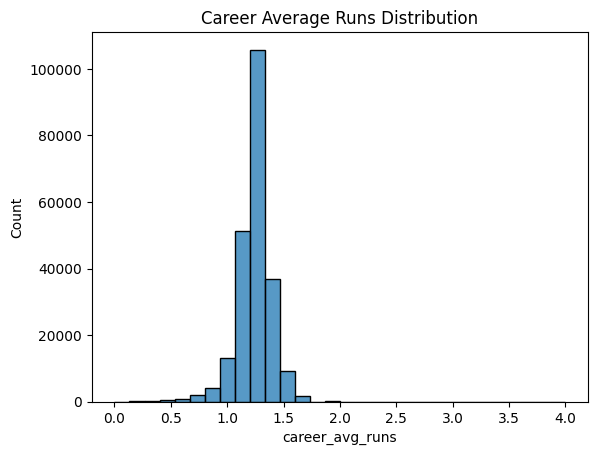

In [27]:
plt.figure()
sns.histplot(features['career_avg_runs'], bins=30)
plt.title("Career Average Runs Distribution")
plt.show()


In [28]:
features.to_csv("engineered_features.csv", index=False)
